## Tutorial 1: Training Your First Neural Network

Welcome! In this tutorial, we'll dive into the intuition and code behind training a machine learning model.

### 1. The Intuition: The "Guess and Check" Loop
Imagine you are trying to learn how to throw a basketball into a hoop.

*   **The Guess:** You throw the ball.
*   **The Check:** You see how far it was from the hoop (the "Error").
*   **The Adjustment:** You adjust your aim and power based on that error.
*   **Repeat:** You keep doing this until you consistently hit the hoop.

In Machine Learning, this is exactly what happens:

*   **Data:** Your previous throws (inputs) and where they landed (outputs).
*   **Model:** Your brain's strategy for throwing.
*   **Loss Function:** The measurement of how far you missed.
*   **Optimiser:** Your brain's method for adjusting the strategy.

You can think of this as trying to 'approximate a function'. The good news for us is that nearly everything is a function. Throwing a ball, predicting if an image is a dog or a cat, predicting language, all functions. This means that we can work with nearly any type of data, as long as there is some sort of pattern.

### 2. Setting Up Our Playground
We'll use TensorFlow (Google's ML library) and some helper tools to create data points.

In [12]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.19.0


### 3. Creating Our Data: Housing Prices
We'll create a simple scenario: Square Footage vs. House Price. We know that generally, the bigger the house, the higher the price. Let's generate 1000 data points.

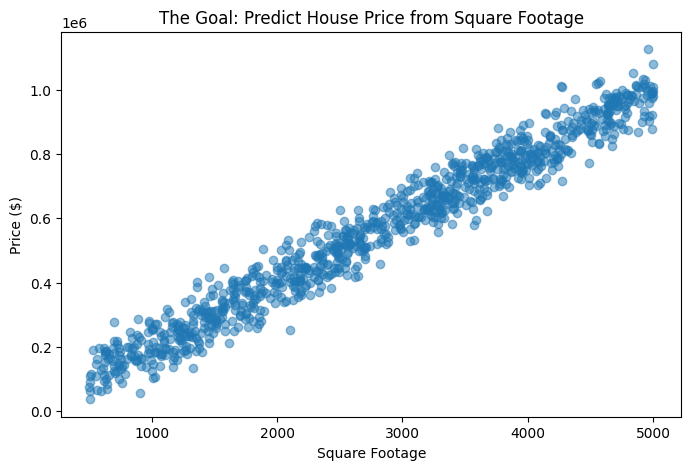

In [13]:
# Generate 1000 houses
np.random.seed(42)
X = np.random.randint(500, 5000, 1000) # Square footage between 500 and 5000
y = (X * 200) + np.random.normal(0, 50000, 1000) # Price = $200/sqft + some noise

# Normalise the data (Neural networks perform better with small numbers)
X_norm = X / 5000.0
y_norm = y / 1000000.0

# Visualise
plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.5)
plt.title("The Goal: Predict House Price from Square Footage")
plt.xlabel("Square Footage")
plt.ylabel("Price ($)")
plt.show()

### 4. Building the Model
Think of a Neural Network as a series of "filters" that interpret the data.

*   `Dense(10)`: A layer that looks for relationships.
*   `Dense(1)`: The final output (the predicted price).

#### 4.1 Creating the Architecture
We stack the layers on top of each other to give them capacity to 'learn'. Layers are composed of 'neurons', typically, the more neurons we have, the better the model is at learning. However, more neurons = larger, slower model that takes longer to train. For simple predictions like this, two layers of ten neurons is enough.

When building the architecture, it is important to think about the input and output sizes. Think, what size is the input to this layer? For the first layer, it will be an input size of one since we only need the square footage. This can be tricky, so feel free to ask for help or use AI.

**Docs:**
*   [Keras Sequential Model](https://www.tensorflow.org/api_docs/python/tf/keras/Sequential)
*   [tf.keras.layers.Dense](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense)
*   [tf.keras.Model.summary](https://www.tensorflow.org/api_docs/python/tf/keras/Model#summary)

#### 4.2 Compiling the model
Here we set up the 'options' for our model. We need to pick a 'loss function' (what do we want to minimise?), an 'optimiser' (methodology for minimising loss) and a 'metric' (track throughout the training phase to see how well it is going).

Note that 'params' correspond to the size of the model. More params means more power to approximate the function or understand the pattern

**Docs:**
*   [tf.keras.Model.compile](https://www.tensorflow.org/api_docs/python/tf/keras/Model#compile)

Now we should have our architecture, our compilation options and our data. These are the only ingredients we need to train a model!

In [14]:
# 1. Create the architecture
model = tf.keras.Sequential([
  tf.keras.layers.Dense(10, input_shape=[1]), # We want a single number (footage) as input
  tf.keras.layers.Dense(10),
  tf.keras.layers.Dense(1) # We want a single number (price) as output
])

# 2. Compile the model
model.compile(loss=tf.keras.losses.MeanSquaredError(),
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              metrics=["mae"])

# 3. Print a summary of the model
model.summary() # Hint: search for 'summary' in the model docs

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141 (564.00 B)

 Trainable params: 141 (564.00 B)

 Non-trainable params: 0 (0.00 B)

### 5. The Training Process
Now we run the loop! We'll go through the data 50 times (epochs).

Remember, data is a key ingredient here. Consult the documentation for 'model.fit' and find a way to include your data in the training process.

**Docs:** [tf.keras.Model.fit()](https://www.tensorflow.org/api_docs/python/tf/keras/Model#fit)

In [15]:
# 1. Train the model
history = model.fit(X_norm, y_norm, epochs=50, verbose=1)

print("Training Complete!")

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0697 - mae: 0.2054
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0041 - mae: 0.0513
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0027 - mae: 0.0413
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0028 - mae: 0.0423
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0028 - mae: 0.0422
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0029 - mae: 0.0433
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0025 - mae: 0.0397
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0030 - mae: 0.0445
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0028 - mae: 0.0425
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0026 - mae: 0.0406
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0026 - mae: 0.0415
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0026 - mae: 0.0409
Epoch 13/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/ste

### 6. How did we learn?
Let's look at the "Loss Curve". As the error goes down, our price predictions are getting more accurate.

Remember, the loss curve represents how well we have optimised the value we chose. We can see that the more we train, the lower the 'loss' gets - this means our model is learning how to predict housing prices based on the data we have given it. Lower loss is better, it typically means that it performs more accurately when predicting.

**Docs:**
*   [matplotlib.pyplot.plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html)

Well done! You just trained a machine learning model. You now have a model that can predict the price of a house based off of square footage.

You might ask, 'just how good is my model?'. A natural question and the focus of our next session, 'Model Evaluation in Machine Learning'. For now, make a prediction with your model in the extension.

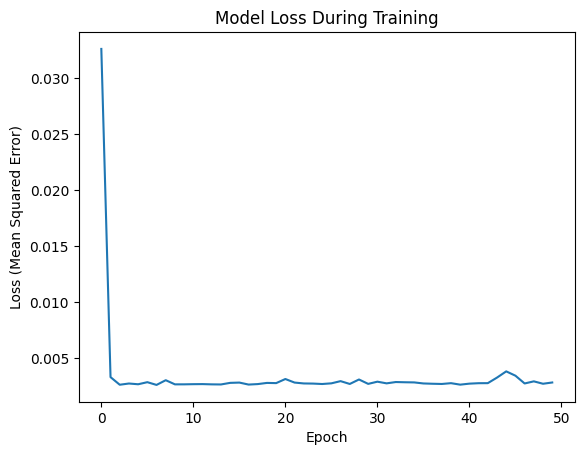

In [16]:
plt.plot(history.history['loss'])
plt.title("Model Loss During Training")
plt.xlabel("Epoch")
plt.ylabel("Loss (Mean Squared Error)")
plt.show()

### 7. Extension (15 Mins): Seeing the Prediction
Let's see if the model can predict the price of a 3000 sqft house.

**Docs:** [tf.keras.Model.predict()](https://www.tensorflow.org/api_docs/python/tf/keras/Model#predict)

In [17]:
sqft_to_predict = 2000

# Normalise (AI models work better with smaller numbers)
norm_sqft = np.array([sqft_to_predict / 5000.0])

# Predict
prediction = model.predict(norm_sqft)
predicted_price = prediction[0][0] * 1000000

# Calculate the expected actual price based on the original data generation formula (without noise)
expected_actual_price = sqft_to_predict * 200

print(f"A {sqft_to_predict} sqft house is predicted to cost: ${predicted_price:,.2f}")
print(f"The expected actual price for a {sqft_to_predict} sqft house (without noise) is: ${expected_actual_price:,.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
A 2000 sqft house is predicted to cost: $422,075.72
The expected actual price for a 2000 sqft house (without noise) is: $400,000.00


### 8. Extension: Simple Regression Model
To demonstrate that the training process is consistent across different model types, let's build a very simple linear regression model using the same X_norm and y_norm data. The steps will look very similar to how we built and trained our Neural Network.

In [18]:
# 1. Create a simple linear regression model
linear_model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[1]) # One neuron, one input feature is typical for simple linear regression
])

# 2. Compile the linear model
linear_model.compile(loss=tf.keras.losses.MeanSquaredError(),
                     optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                     metrics=["mae"])

# 3. Print a summary
linear_model.summary()

# Docs:
# - [tf.keras.layers.Dense](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense)
# - [tf.keras.Model.compile](https://www.tensorflow.org/api_docs/python/tf/keras/Model#compile)
# - [tf.keras.Model.summary](https://www.tensorflow.org/api_docs/python/tf/keras/Model#summary)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

#### 8.1 Training the Linear Model
Now, let's train this simple linear model. Notice how the `model.fit()` function is used in the same way as with the neural network.

In [19]:
# 1. Train the linear model
history_linear = linear_model.fit(X_norm, y_norm, epochs=50, verbose=0)

print("Linear Model Training Complete!")

# Docs:
# - [tf.keras.Model.fit()](https://www.tensorflow.org/api_docs/python/tf/keras/Model#fit)

Linear Model Training Complete!


#### 8.2 Linear Model Loss Curve
Just like with our neural network, we can inspect the loss curve of the linear regression model to see how it learned. The goal is the same: to minimize the loss.

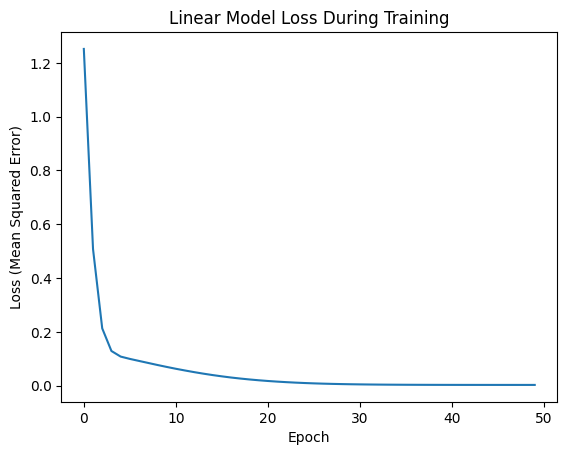

In [20]:
plt.plot(history_linear.history['loss'])
plt.title("Linear Model Loss During Training")
plt.xlabel("Epoch")
plt.ylabel("Loss (Mean Squared Error)")
plt.show()

# Docs:
# - [matplotlib.pyplot.plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html)

#### 8.3 Linear Model Prediction
Let's use our simple linear model to predict the price of a 3000 sqft house. The prediction method is identical.

In [21]:
sqft_to_predict_linear = 3000
norm_sqft_linear = np.array([sqft_to_predict_linear / 5000.0])

prediction_linear = linear_model.predict(norm_sqft_linear)
actual_price_linear = prediction_linear[0][0] * 1000000

print(f"A {sqft_to_predict_linear} sqft house is predicted to cost: ${actual_price_linear:,.2f} by the linear model.")

# Docs:
# - [tf.keras.Model.predict()](https://www.tensorflow.org/api_docs/python/tf/keras/Model#predict)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
A 3000 sqft house is predicted to cost: $602,945.69 by the linear model.


### 9. The Universal Training Loop
As you've seen with both the Neural Network and the simple Linear Regression model, the fundamental training process remains the same:

1.  **Define the Model Architecture:** Choose a model that suits your data and problem (e.g., a simple linear model, a multi-layered neural network).
2.  **Compile the Model:** Specify how the model will learn by choosing:
    *   A Loss Function (how to measure error).
    *   An Optimizer (how to adjust the model to reduce error).
    *   Metrics (what to track during training).
3.  **Train the Model:** Feed the model your data and let it iterate through the 'guess and check' loop (epochs) to learn the patterns.
4.  **Evaluate and Predict:** Once trained, assess how well the model performs and use it to make predictions on new data.

This 'guess and check' loop is the heart of most machine learning and deep learning algorithms, making these core principles applicable across a vast range of tasks and models, regardless of their complexity.